In [35]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [36]:
import os
os.chdir("../original_case_data")

abm = pd.read_parquet("abm.parquet")
card = pd.read_parquet("card.parquet")
cheque = pd.read_parquet("cheque.parquet")
eft = pd.read_parquet("eft.parquet")
emt = pd.read_parquet("emt.parquet")
westernUnion = pd.read_parquet("westernunion.parquet")
wire = pd.read_parquet("wire.parquet")

channels = {
    "ABM": abm,
    "Card": card,
    "Cheque": cheque,
    "EFT": eft,
    "EMT": emt,
    "Western Union": westernUnion,
    "Wire": wire
}

kyc_ind = pd.read_parquet("kyc_individual.parquet")
kyc_ind_codes = pd.read_parquet("kyc_industry_codes.parquet")
kyc_occ_codes = pd.read_parquet("kyc_occupation_codes.parquet")
kyc_sb = pd.read_parquet("kyc_smallbusiness.parquet")
label = pd.read_parquet("labels.parquet")

In [37]:
def coerce_code_to_str(df, col):
    if col in df.columns:
        df = df.copy()
        df[col] = df[col].astype("string").str.strip()
    return df

# --- 1) Stack transactions ---
transactions = []
for channel_name, df in channels.items():
    d = df.copy()
    d["channel"] = channel_name

    d = d.rename(columns={
        "country": "tx_country",
        "province": "tx_province",
        "city": "tx_city"})

    transactions.append(d)

tx = pd.concat(transactions, axis=0, ignore_index=True)

# 2) Coerce join keys for KYC code tables
kyc_ind_  = coerce_code_to_str(kyc_ind, "occupation_code")
kyc_occ_  = coerce_code_to_str(kyc_occ_codes, "occupation_code")

kyc_sb_   = coerce_code_to_str(kyc_sb, "industry_code")
kyc_indc_ = coerce_code_to_str(kyc_ind_codes, "industry_code")

# 3) Merge code lookups onto KYC
kyc_ind_full = kyc_ind_.merge(kyc_occ_, on="occupation_code", how="left")
kyc_ind_full["customer_type"] = "individual"

kyc_sb_full = kyc_sb_.merge(kyc_indc_, on="industry_code", how="left")
kyc_sb_full["customer_type"] = "small_business"

# 4) Union KYC tables (different schemas)
common_cols = sorted(set(kyc_ind_full.columns) | set(kyc_sb_full.columns))
kyc_ind_full = kyc_ind_full.reindex(columns=common_cols)
kyc_sb_full  = kyc_sb_full.reindex(columns=common_cols)

kyc = pd.concat([kyc_ind_full, kyc_sb_full], ignore_index=True)

# Rename KYC geo fields AFTER union (so you only do it once)
kyc = kyc.rename(columns={
    "country": "kyc_country",
    "province": "kyc_province",
    "city": "kyc_city"
})

# 5) Merge labels onto KYC  (unchanged)
kyc = kyc.merge(label, on="customer_id", how="left")

# 6) Merge transactions with KYC (no duplicate geo columns now)
data = tx.merge(
    kyc,
    on="customer_id",
    how="left",
    validate="many_to_one")

# --- 7) Quick checks ---
print("tx rows:", len(tx), "unique customers in tx:", tx["customer_id"].nunique())
print("kyc rows:", len(kyc), "unique customers in kyc:", kyc["customer_id"].nunique())
print("final rows:", len(data))
print("KYC match rate:", data["customer_type"].notna().mean())
print("Label availability rate:", data["label"].notna().mean())


/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_42488/549444387.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  kyc = pd.concat([kyc_ind_full, kyc_sb_full], ignore_index=True)


tx rows: 5903333 unique customers in tx: 61410
kyc rows: 61410 unique customers in kyc: 61410
final rows: 5903333
KYC match rate: 1.0
Label availability rate: 0.009945229245919212


In [38]:
all_features = pd.read_parquet("../all_features.parquet")
all_features.head()

,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,...,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,...,0.706175,0,0,0,0.0,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,...,-0.291106,0,0,0,0.0,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,...,0.328867,0,0,0,0.0,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,...,-0.968301,0,0,0,0.0,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,...,0.661526,0,0,0,0.0,2,12,40,0.598174,0.926941


# fit an mixed effect model w random effect for customer, use random intercept as feature in model

In [39]:
import statsmodels.formula.api as smf

data["log_amount"] = np.log1p(data["amount_cad"])

model = smf.mixedlm(
    "log_amount ~ 1",
    data,
    groups=data["customer_id"])

result = model.fit()

print(result.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_amount    
No. Observations: 5903333 Method:             REML          
No. Groups:       61410   Scale:              2.6618        
Min. group size:  1       Log-Likelihood:     -11355344.0340
Max. group size:  4991    Converged:          Yes           
Mean group size:  96.1                                      
-------------------------------------------------------------
             Coef.  Std.Err.     z      P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept    4.537     0.004  1215.243  0.000   4.530   4.544
Group Var    0.771     0.003                                 



In [40]:
random_effects = pd.DataFrame.from_dict(
    result.random_effects,
    orient="index")

random_effects.columns = ["random_intercept"]

random_effects["customer_id"] = random_effects.index

random_effects = random_effects.reset_index(drop=True)

In [41]:
all_features = all_features.merge(
    random_effects,
    on="customer_id",
    how="left",
    validate="one_to_one")

# try clustering again?

In [42]:
all_features["customer_type_ind"] = np.where(all_features["customer_type"] == "IND", 0, 1)
# kurt_debit, kurt_credit all NA
all_features.drop(["customer_type", "kurt_debit", "kurt_credit"], axis=1, inplace=True)

labelled = all_features[all_features["label"].notnull()]
labelled.drop(["customer_id"], axis=1, inplace=True)

unlabelled = all_features[all_features["label"].isnull()]
unlabelled.drop(["customer_id"], axis=1, inplace=True)

# drop correlated features above threshold 0.9
corr_matrix = labelled.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.9

to_drop = [
    column for column in upper.columns
    if any(upper[column] > threshold)
]

labelled_df = labelled.drop(columns=to_drop)
unlabelled_df = unlabelled.drop(columns=to_drop)

/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_42488/2870743684.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled.drop(["customer_id"], axis=1, inplace=True)
/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_42488/2870743684.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabelled.drop(["customer_id"], axis=1, inplace=True)


In [43]:
imp = IterativeImputer(max_iter=20, random_state=42)

labelled_imp = imp.fit_transform(labelled_df)
unlabelled_imp = imp.transform(unlabelled_df)

labelled_imp = pd.DataFrame(labelled_imp, columns=labelled_df.columns, index=labelled_df.index)
unlabelled_imp = pd.DataFrame(unlabelled_imp, columns=unlabelled_df.columns, index=unlabelled_df.index)
columns = unlabelled_imp.columns

labelled_imp.head()

/Users/rebeccalee/Library/Python/3.11/lib/python/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,rapid_outflow_ratio_24h,mean_debit,...,unique_merchant_categories,msb_channels_n,msb_pass_through_ratio,msb_net_retention_ratio,struct_total_near_n,tx_country_n,pct_tx_province_mismatch,pct_tx_city_mismatch,random_intercept,customer_type_ind
2,0.0,0.037841,0.0,1.460746,1.0,0.0,18.0,0.234281,0.0,1229.440000,...,12.0,3.0,0.505042,0.328867,0.0,1.0,0.75,0.975,0.092446,0.0
103,0.0,0.000000,0.0,0.565197,0.0,0.0,18.0,0.000000,0.0,1192.126667,...,0.0,2.0,0.597853,0.251680,0.0,0.0,1.00,1.000,0.548027,0.0
164,0.0,0.000000,0.0,0.036114,1.0,0.0,18.0,0.000000,0.0,-4785.943883,...,0.0,1.0,0.000000,1.000000,0.0,0.0,1.00,1.000,0.029297,0.0
274,0.0,0.000000,1.0,1.215037,0.0,1.0,17.0,0.000000,0.0,-14471.982234,...,0.0,1.0,0.000000,1.000000,0.0,0.0,1.00,1.000,0.677614,0.0
280,0.0,0.000000,2.0,0.273064,1.0,0.0,18.0,0.000000,0.0,949.250000,...,0.0,2.0,0.488426,0.343701,0.0,0.0,1.00,1.000,0.666633,0.0


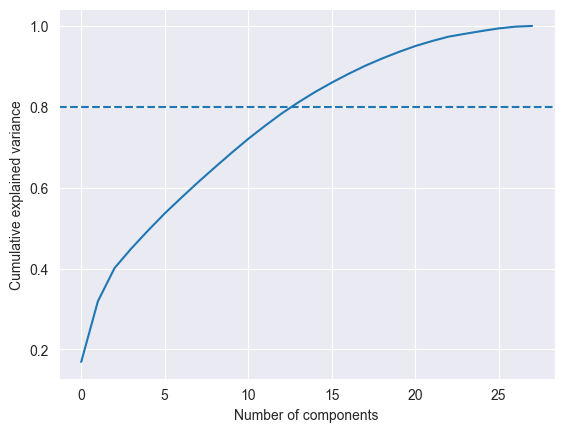

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
cash_value_ratio,0.032951,-0.075741,-0.067380,-0.158889,-0.292041,0.293337,0.500050,0.425096,0.186338,-0.157050,-0.136988,0.092669,-0.276136
emt_velocity_monthly_mean,0.168028,0.074049,0.183689,-0.121333,0.494203,0.099440,-0.092031,0.025599,-0.132284,-0.168013,0.022804,0.277857,-0.274588
income_transaction_gap_score,0.037924,0.133407,0.058437,-0.297552,-0.357814,0.065855,-0.482517,0.187063,-0.130962,0.295241,-0.039190,0.179647,-0.153048
is_retired,-0.076863,0.069178,0.055650,0.329263,-0.492868,-0.160414,0.102841,-0.209329,-0.027079,-0.178312,0.298292,-0.032621,0.001998
is_unemployed,-0.127637,-0.339171,0.111849,0.013631,0.059515,-0.084889,-0.144921,0.093927,-0.013689,0.250112,-0.217061,-0.070159,-0.099611
occupation_sector_id,-0.050819,-0.048326,0.078625,0.368389,-0.193257,-0.228741,0.006960,0.028041,-0.421761,-0.297505,-0.173684,0.293796,-0.397477
spending_income_ratio,0.115198,0.186179,-0.160028,-0.325639,-0.353965,0.064828,-0.244432,0.044261,-0.073461,0.015611,0.067556,0.159822,0.018181
rapid_outflow_ratio_24h,0.031192,-0.007009,0.040393,-0.082034,-0.065090,0.052641,0.440510,-0.324231,-0.370784,0.414947,-0.300193,0.409250,0.320027
mean_debit,0.167914,0.352833,-0.238841,-0.028812,0.024939,0.052122,0.075083,-0.067512,-0.038235,-0.186015,0.156183,0.090763,0.094836
skew_debit,-0.046497,-0.000249,-0.070280,0.217832,0.062145,-0.132052,-0.141832,0.634146,-0.247077,-0.165033,-0.233544,0.057560,0.482567


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

labels = labelled_imp['label']

# drop ID column
X = labelled_imp.drop(columns=['label'])

# normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# visualize
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(y=0.8, linestyle='--')
plt.show()

# re-fit pca with opt # components
pca_opt = PCA(n_components=13)
X_pca = pca_opt.fit_transform(X_scaled)

# variation per principal component by feature
loadings = pd.DataFrame(
    pca_opt.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_opt.n_components_)],
    index=X.columns)

loadings.style.background_gradient(
    cmap="coolwarm",
    subset=[f'PC{i+1}' for i in range(pca_opt.n_components_)])

In [45]:
# most important features for each prinicpal component
loadings['PC1'].abs().sort_values(ascending=False)

mean_velocity                   0.407967
unique_merchant_categories      0.390415
tx_country_n                    0.362478
std_velocity                    0.351558
late_night_txn_count            0.272596
msb_channels_n                  0.259878
activity_span_days              0.234277
random_intercept                0.221836
emt_velocity_monthly_mean       0.168028
mean_debit                      0.167914
mean_credit                     0.160301
pct_tx_city_mismatch            0.152921
is_unemployed                   0.127637
spending_income_ratio           0.115198
pct_tx_province_mismatch        0.096694
msb_net_retention_ratio         0.082422
struct_total_near_n             0.082292
late_night_ratio                0.080558
is_retired                      0.076863
occupation_sector_id            0.050819
skew_debit                      0.046497
income_transaction_gap_score    0.037924
cash_value_ratio                0.032951
rapid_outflow_ratio_24h         0.031192
msb_pass_through

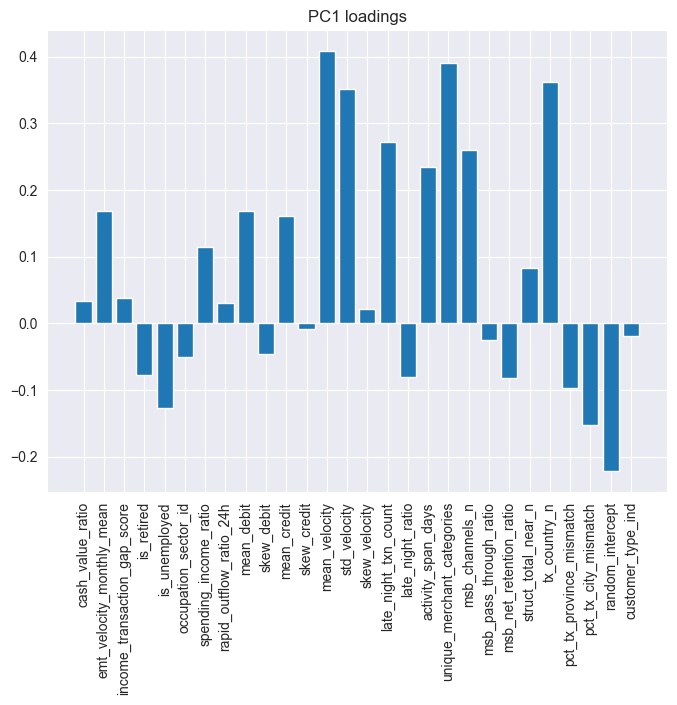

In [46]:
# biplot arrows
plt.figure(figsize=(8,6))
plt.bar(loadings.index, loadings['PC1'])
plt.xticks(rotation=90)
plt.title("PC1 loadings")
plt.show()

In [47]:
# explained variance per each component
explained = pd.DataFrame({
    'PC': range(1, len(pca_opt.explained_variance_ratio_)+1),
    'variance_explained': pca_opt.explained_variance_ratio_})

explained

,PC,variance_explained
0,1,0.169072
1,2,0.149999
2,3,0.082307
3,4,0.048153
4,5,0.044352
5,6,0.042379
6,7,0.039060
7,8,0.038181
8,9,0.036619
9,10,0.035864


In [48]:
X_pca_data = X.copy()

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X_pca_data['cluster'] = clusters

tmp = pd.DataFrame({"label": labels, "cluster": clusters}, index=X_pca_data.index)
labelled_tmp = tmp[tmp["label"].notna()]

cluster_profile = (labelled_tmp.groupby("cluster")["label"]
                   .agg(labeled_count="count", positives="sum", positive_rate="mean")
                   .reset_index()
                   .sort_values("positive_rate", ascending=False))
cluster_profile

,cluster,labeled_count,positives,positive_rate
4,4,24,3.0,0.125000
2,2,104,2.0,0.019231
3,3,421,3.0,0.007126
0,0,188,1.0,0.005319
1,1,263,1.0,0.003802


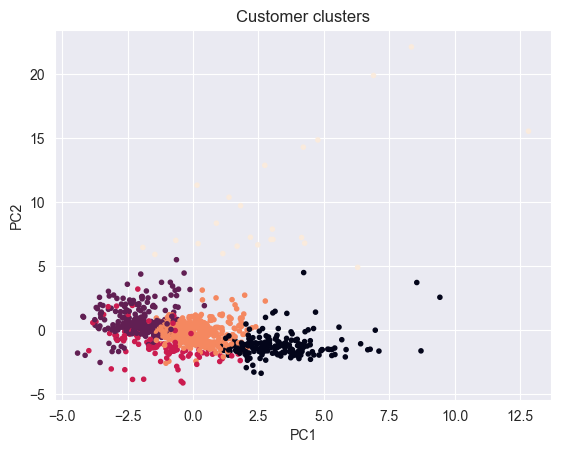

In [49]:
# visualize 2D clusters
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, marker=".")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer clusters")
plt.show()

^adding a transaction-level modeled feature did not make the clusters any better